<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px;">
  <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal" width="250">
  <h1 style="color: #007bff; font-size: 24px;">Bootcamp de Visão Computacional com Drones</h1>
  <h3 style="color: #343a40; font-size: 20px;">Projeto 4: Baseline e contagem por imagem</h3>
  <p style="color: #6c757d; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>


# Baseline e contagem por imagem

Vamos medir o desempenho de um YOLO11n pré-treinado em COCO, sem atualizar os pesos. Escolheremos o limiar na validação e avaliaremos o teste com essa decisão congelada.

Este notebook é independente: os dados necessários acompanham o repositório. No Colab, selecione **Copiar para o Drive** e execute as células na ordem. Selecione uma GPU em Ambiente de execução > Alterar tipo de ambiente de execução.

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlosfab/bootcamp-visao-computacional-drones/blob/codex/projeto-4-gado/projeto-4/01_baseline_e_contagem.ipynb)


## Ambiente

A primeira célula obtém os arquivos da versão do projeto e instala as dependências. O PyTorch fornecido pelo ambiente será preservado; sua versão será registrada. Se já importou bibliotecas antes desta instalação, reinicie o ambiente e execute novamente desde o início.

Os arquivos de trabalho ficam em `dados/`, `pesos/` e `resultados/`. As pastas de métricas e figuras têm nomes fixos e seus arquivos são atualizados ao reexecutar. Antes de repetir o experimento ou encerrar o Colab, baixe o ZIP seguindo as instruções ao final.


In [1]:
from pathlib import Path
import os
import subprocess
import sys
if not Path("suporte").is_dir():
    destino = Path("/content/bootcamp-gado")
    if not destino.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", "--branch", "codex/projeto-4-gado",
                        "https://github.com/carlosfab/bootcamp-visao-computacional-drones.git", str(destino)], check=True)
    subprocess.run(["git", "-C", str(destino), "sparse-checkout", "set", "projeto-4"], check=True)
    os.chdir(destino / "projeto-4")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], returncode=0)

In [2]:
import json
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from suporte.preparar_dados import obter_dados
from suporte.experimento import inventario, ler_caixas, desenhar
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12,
                     "font.family": "sans-serif", "axes.grid": False})


A semente controla parte da aleatoriedade, mas versões, hardware e operações numéricas também influenciam o resultado. O registro abaixo identifica o ambiente desta execução, sem prometer identidade bit a bit entre CPU e GPU.


In [3]:
import torch
from ultralytics import YOLO
from importlib.metadata import version
from suporte.experimento import inferir, calibrar, salvar_resultado
from suporte.contagem import evaluate_predictions
DISPOSITIVO = 0 if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DISPOSITIVO)


Dispositivo: 0


In [4]:
SAIDA = Path("resultados/baseline")
SAIDA.mkdir(parents=True, exist_ok=True)
pacotes = ["numpy", "pandas", "matplotlib", "Pillow", "ultralytics", "torch"]
ambiente = {nome: version(nome) for nome in pacotes}
ambiente["python"] = platform.python_version()
ambiente["sistema"] = platform.platform()
ambiente["dispositivo"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
(SAIDA / "ambiente.json").write_text(json.dumps(ambiente, indent=2))
display(ambiente)


{'numpy': '2.2.6',
 'pandas': '2.2.3',
 'matplotlib': '3.9.4',
 'Pillow': '11.3.0',
 'ultralytics': '8.3.203',
 'torch': '2.11.0+cu128',
 'python': '3.13.15',
 'sistema': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'dispositivo': 'Tesla T4'}

## Dados e partições

O recorte didático contém **300 imagens** de bovinos a pasto: 180 de treino, 60 de validação e 60 de teste. As imagens derivam do ICAERUS v2, com lado maior limitado a 2048 pixels e anotações YOLO de uma classe, `cow`. A atribuição e a licença CC BY 4.0 acompanham os dados.

Treino e validação usam Mauron e Jalogny em datas separadas. O teste usa Derval, uma fazenda ausente do desenvolvimento. Datas e voos não atravessam partições, mas os animais não têm identificadores individuais. A avaliação mede contagem **por imagem**, não um censo de indivíduos únicos.


In [5]:
RAIZ = obter_dados()
tabela = inventario(RAIZ)
manifesto = json.loads((RAIZ / "manifesto.json").read_text())
treino = tabela[tabela["split"] == "train"].copy()
validacao = tabela[tabela["split"] == "val"].copy()
teste = tabela[tabela["split"] == "test"].copy()
assert [len(treino), len(validacao), len(teste)] == [180, 60, 60]
print("Imagens de treino, validação e teste:", len(treino), len(validacao), len(teste))


Imagens de treino, validação e teste: 180 60 60


## Um detector genérico como referência

O **baseline** estabelece o que o modelo já consegue fazer. O identificador numérico de `cow` no COCO não precisa ser zero: a função de inferência seleciona a classe pelo nome e remapeia a saída para a classe única deste conjunto. Os pesos iniciais serão baixados pela biblioteca, sem chave de API.


In [6]:
modelo = YOLO("yolo11n.pt")
classes_bovino = {i: nome for i, nome in modelo.names.items() if nome in {"cow", "cattle"}}
assert classes_bovino, "Classe de bovino não encontrada."
display(classes_bovino)
hash_peso = hashlib.sha256(Path("yolo11n.pt").read_bytes()).hexdigest()
print("SHA-256 dos pesos:", hash_peso)


{19: 'cow'}

SHA-256 dos pesos: 0ebbc80d4a7680d14987a577cd21342b65ecfd94632bd9a8da63ae6417644ee1


## Contagem correta não garante detecção correta

Com $N$ imagens, o erro absoluto médio é $\operatorname{MAE}=\frac{1}{N}\sum_i |\hat{y}^{(i)}-y^{(i)}|$, em bovinos por imagem. O viés usa a diferença com sinal: negativo indica subcontagem e positivo, supercontagem.

Para avaliar localização, associamos cada previsão a no máximo uma anotação, com **IoU de pelo menos 0,5**. Precisão, recall e F1 agregam TP, FP e FN sobre todas as imagens. São métricas em um ponto de operação, não AP ou mAP.

No exemplo sintético abaixo, uma caixa correta e outra deslocada produzem a contagem certa, mas deixam um falso positivo e um falso negativo.


In [7]:
caso = {"image_id": "exemplo", "gt_boxes": [[0, 0, 10, 10], [20, 0, 30, 10]],
        "pred_boxes": [[0, 0, 10, 10], [40, 0, 50, 10]], "scores": [0.9, 0.8]}
display(evaluate_predictions([caso], conf_threshold=0.25)["summary"])


{'tp': 1,
 'fp': 1,
 'fn': 1,
 'precision': 0.5,
 'recall': 0.5,
 'f1': 0.5,
 'n_images': 1,
 'mae': 0.0,
 'rmse': 0.0,
 'bias': 0.0,
 'exact_accuracy': 1.0,
 'exact_match_count': 1,
 'conf_threshold': 0.25,
 'iou_threshold': 0.5}

## Calibrar somente na validação

A inferência guarda candidatos com confiança a partir de 0,05 e entrada de 640 pixels. Assim, podemos avaliar vários limiares sem executar novamente o detector. A regra é **maior F1 na validação**; em empate, menor MAE e depois maior limiar.

Essa escolha procura equilibrar localização e contagem. Ela não garante o melhor resultado em outra fazenda, e a confiança do detector não é uma probabilidade calibrada de acerto.


In [8]:
previsoes_val = inferir(modelo, validacao, device=DISPOSITIVO)
limiar, calibracao = calibrar(previsoes_val)
calibracao.to_csv(SAIDA / "calibracao.csv", index=False)
display(calibracao[["threshold", "precision", "recall", "f1", "mae"]])
print("Limiar escolhido:", limiar)


,threshold,precision,recall,f1,mae
0,0.05,0.0,0.0,0.0,4.633333
1,0.10,0.0,0.0,0.0,4.633333
2,0.15,0.0,0.0,0.0,4.633333
3,0.20,0.0,0.0,0.0,4.633333
4,0.25,0.0,0.0,0.0,4.633333
5,0.30,0.0,0.0,0.0,4.633333
6,0.40,0.0,0.0,0.0,4.633333
7,0.50,0.0,0.0,0.0,4.633333
8,0.60,0.0,0.0,0.0,4.633333
9,0.70,0.0,0.0,0.0,4.633333


Limiar escolhido: 0.8


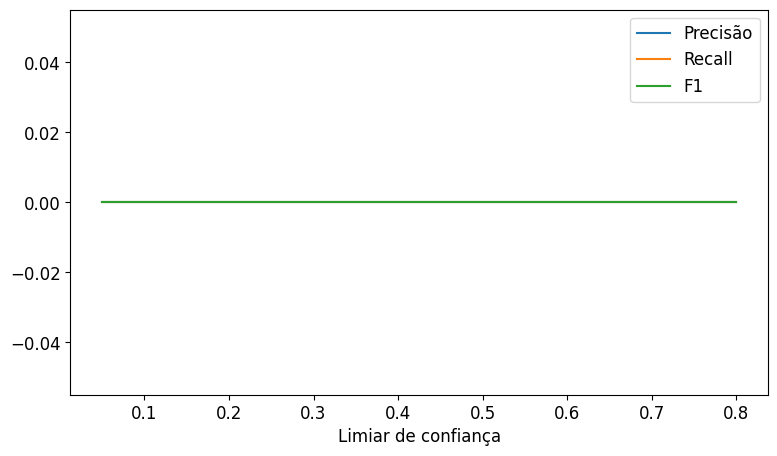

In [9]:
plt.plot(calibracao["threshold"], calibracao["precision"], label="Precisão")
plt.plot(calibracao["threshold"], calibracao["recall"], label="Recall")
plt.plot(calibracao["threshold"], calibracao["f1"], label="F1")
plt.xlabel("Limiar de confiança")
plt.legend()
plt.show()


Antes de abrir o teste, salvamos as escolhas do experimento. A biblioteca aplica sua supressão de caixas por imagem; o caminho de inferência será o mesmo na comparação posterior com fine-tuning. O manifesto identifica os dados utilizados.


In [10]:
configuracao = {"modelo": "yolo11n.pt", "weights_sha256": hash_peso,
                "imgsz": 640, "conf": limiar, "iou_match": 0.5,
                "selecao": "F1 val; empate por menor MAE e maior confiança",
                "manifest_sha256": hashlib.sha256((RAIZ / "manifesto.json").read_bytes()).hexdigest()}
(SAIDA / "configuracao.json").write_text(json.dumps(configuracao, indent=2))
resumo_val = salvar_resultado(SAIDA / "val", previsoes_val, limiar)


## Avaliação congelada em Derval

O teste contém uma fazenda ausente do desenvolvimento. Isso oferece um caso de mudança de domínio, sem garantir generalização para todas as fazendas. Imagens de um mesmo voo ainda são correlacionadas; sessenta imagens não equivalem a sessenta fazendas independentes.


In [11]:
previsoes_teste = inferir(modelo, teste, device=DISPOSITIVO)
resumo = salvar_resultado(SAIDA / "test", previsoes_teste, limiar)
chaves = ["n_images", "precision", "recall", "f1", "mae", "rmse", "bias", "exact_accuracy"]
display(pd.Series({chave: resumo[chave] for chave in chaves}, name="Teste"))
display(resumo["by_presence"])
display(resumo["timing"])


,Teste
n_images,60.000000
precision,0.000000
recall,0.000000
f1,0.000000
mae,1.850000
rmse,3.888016
bias,-1.850000
exact_accuracy,0.666667


{'positive': {'tp': 0,
  'fp': 0,
  'fn': 111,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'n_images': 20,
  'mae': 5.55,
  'rmse': 6.734240862933253,
  'bias': -5.55,
  'exact_accuracy': 0.0,
  'exact_match_count': 0,
  'conf_threshold': 0.8,
  'iou_threshold': 0.5},
 'negative': {'tp': 0,
  'fp': 0,
  'fn': 0,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'n_images': 40,
  'mae': 0.0,
  'rmse': 0.0,
  'bias': 0.0,
  'exact_accuracy': 1.0,
  'exact_match_count': 40,
  'conf_threshold': 0.8,
  'iou_threshold': 0.5,
  'false_positive_image_rate': 0.0}}

{'n_timed_images': 60,
 'total_seconds': 1.8816354549987864,
 'mean_seconds': 0.03136059091664644}

A taxa de contagem exata considera imagens positivas e negativas. Confira também as métricas separadas: muitas imagens vazias podem tornar a média agregada favorável mesmo quando bovinos são omitidos. Nos negativos, a taxa de imagens com falso positivo mede quantas cenas vazias receberam pelo menos uma caixa.

O tempo inclui a chamada ao modelo e seu pós-processamento, mas exclui a leitura das imagens e anotações. A primeira chamada pode conter aquecimento; essas medidas são descritivas desta execução, não um benchmark rigoroso.


## Examinar erros concretos

A galeria seleciona as imagens com mais falsos positivos e falsos negativos, usando o limiar já congelado. **Verde** representa a anotação; **vermelho tracejado**, a previsão. Uma contagem correta pode esconder uma omissão compensada por uma caixa falsa.

Depois desta inspeção, registre hipóteses de falha. Uma alteração motivada pelo teste passa a ser exploração e exigiria outro conjunto independente para uma nova avaliação final.


In [12]:
por_imagem = pd.read_csv(SAIDA / "test" / "per_image.csv")
por_imagem["falhas"] = por_imagem["fp"] + por_imagem["fn"]
casos = por_imagem.sort_values(["falhas", "image_id"], ascending=[False, True]).head(4)
display(casos[["image_id", "gt_count", "pred_count", "fp", "fn"]])
indice = {linha["image_id"]: linha for linha in previsoes_teste}
(SAIDA / "galeria").mkdir(exist_ok=True)


,image_id,gt_count,pred_count,fp,fn
34,test/derval__DJI_20230809151124_0008_V.jpg,13,0,0,13
6,test/derval__DJI_20230809145619_0021_V.jpg,12,0,0,12
7,test/derval__DJI_20230809145620_0022_V.jpg,12,0,0,12
5,test/derval__DJI_20230809145618_0020_V.jpg,11,0,0,11


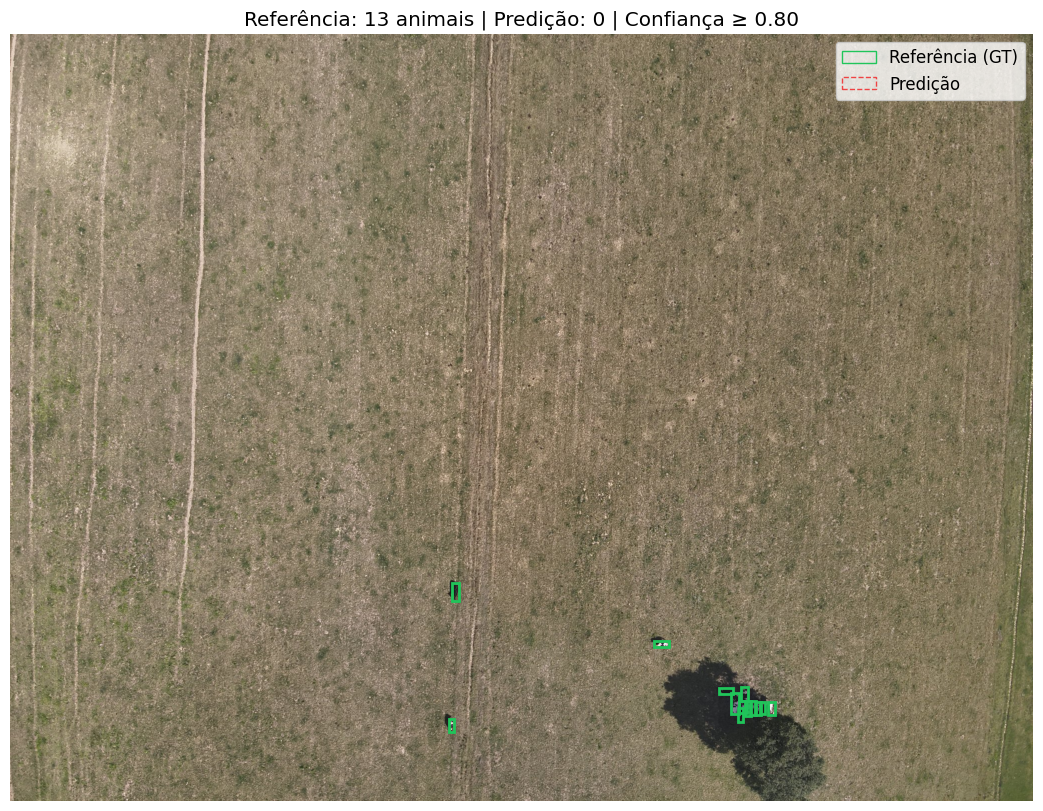

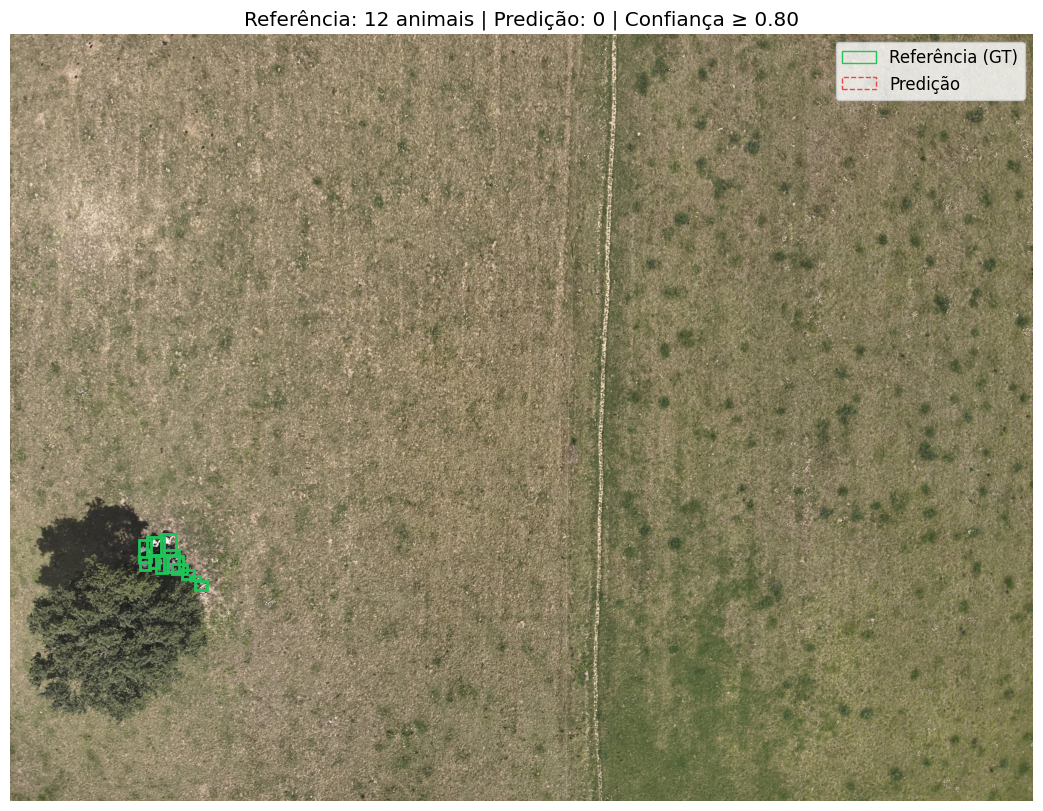

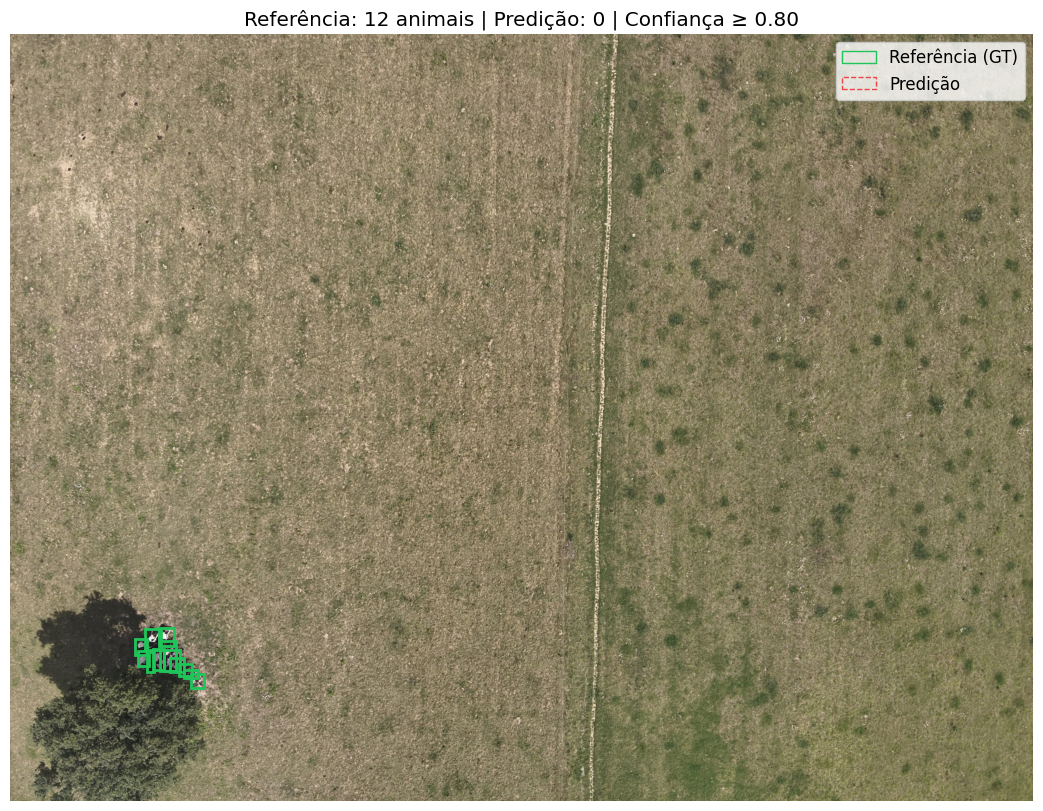

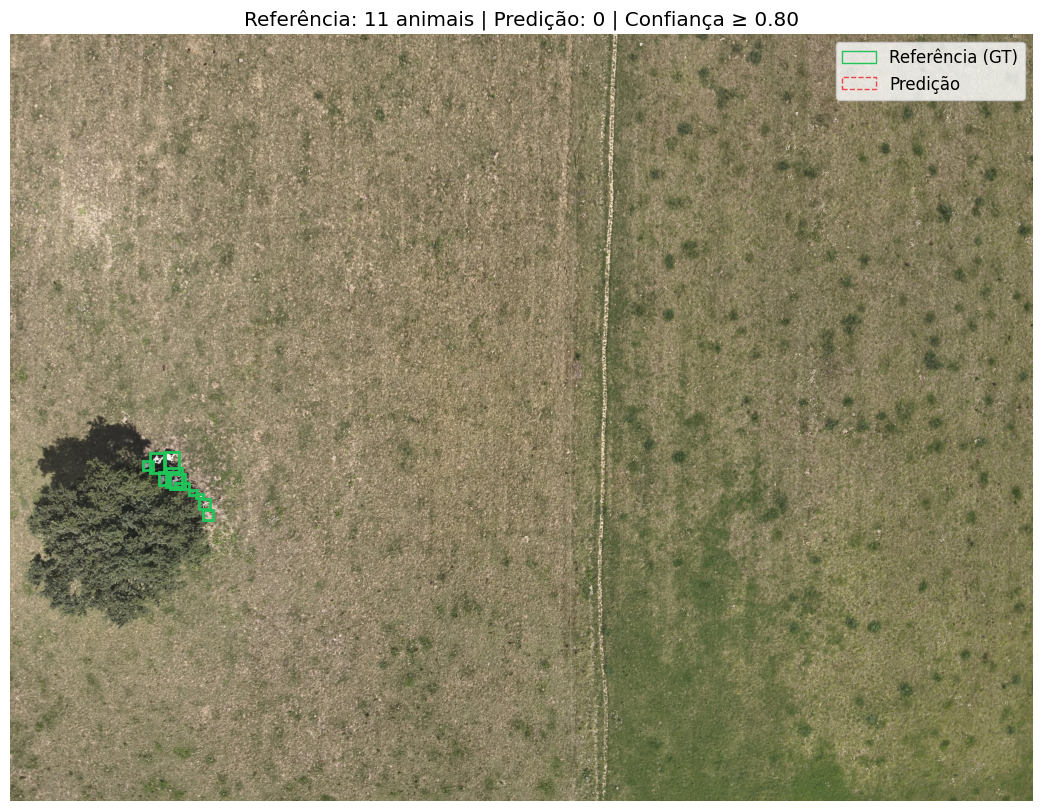

In [13]:
for numero, image_id in enumerate(casos["image_id"]):
    linha = indice[image_id]
    figura = desenhar(linha["image"], linha["gt_boxes"], linha["pred_boxes"],
                      linha["scores"], limiar)
    figura.savefig(SAIDA / "galeria" / f"caso_{numero}.png", dpi=120)
    plt.show()
    plt.close(figura)


## Conclusão do baseline

Registre o principal tipo de erro, o MAE no teste e uma limitação desta avaliação. Não ajuste o limiar para melhorar as imagens da galeria. No fine-tuning, a pergunta será se a adaptação do mesmo modelo ao domínio modifica esse comportamento.


## Salvar a execução

A pasta de um treinamento concluído é protegida contra reutilização; uma nova tentativa exige outro `name`. Já as pastas de métricas, configurações e figuras têm nomes fixos e são atualizadas ao reexecutar os notebooks. Baixe os resultados **antes de repetir** ou encerrar o runtime.

No Colab, copie o trecho opcional abaixo para uma nova célula e execute-o quando quiser baixar a execução. O ZIP inclui `resultados/` inteiro, os pesos treinados que estiverem nessa pasta e o manifesto. O checkpoint de referência do notebook de recortes continua disponível nos arquivos do projeto e é identificado pelo hash da configuração.

```python
import shutil
from datetime import datetime
from google.colab import files
shutil.copy("assets/manifesto.json", "resultados/manifesto.json")
nome = "resultados-projeto4-" + datetime.now().strftime("%Y%m%d-%H%M%S")
arquivo = shutil.make_archive(nome, "zip", "resultados")
files.download(arquivo)
```

Salve também este notebook com suas saídas em **Arquivo > Salvar** na cópia do Drive, ou use **Arquivo > Fazer download > Fazer download do .ipynb**. A cópia do notebook não salva automaticamente os arquivos temporários do runtime. Localmente, compacte `resultados/` ou use as mesmas linhas sem importar `google.colab` e sem chamar `files.download`.
